# 02 - Data Preprocessing
Load filtered dataset from Week 2, handle missing values, outliers, encoding, and train/test split.

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os

## 1. Load and Combine Data 
#### (same as 01_exploration)

In [2]:
# Find all CRMLS files, exclude the pre-processed one
file_list = glob.glob("data/CRMLSSold*.csv")
clean_files = [f for f in file_list if "_filled" not in f]

# Load and combine all files
df_list = []
for file in clean_files:
    temp_df = pd.read_csv(file, low_memory=False)
    df_list.append(temp_df)

df = pd.concat(df_list, ignore_index=True)

# Apply the dual filter
df = df[(df['PropertyType'] == 'Residential') & (df['PropertySubType'] == 'SingleFamilyResidence')]

print('Shape after load + filter:', df.shape)

Shape after load + filter: (230343, 78)


## 2. Handle ClosePrice Outliers
Rows with ClosePrice > $100M are data entry errors, not real sales. Drop these before imputing other columns so the median isn't skewed.

In [3]:
print('Rows with ClosePrice > $100M:', (df['ClosePrice'] > 100000000).sum())

# Remove unrealistic prices
df = df[df['ClosePrice'] <= 100000000]

# Remove $0 or negative prices — log-transform can't handle these
print('Rows with ClosePrice <= 0:', (df['ClosePrice'] <= 0).sum())
df = df[df['ClosePrice'] > 0]

# Drop the 1 row missing ClosePrice entirely (can't impute a target variable)
df = df.dropna(subset=['ClosePrice'])

print('Shape after cleaning ClosePrice:', df.shape)

Rows with ClosePrice > $100M: 25
Rows with ClosePrice <= 0: 1
Shape after cleaning ClosePrice: (230316, 78)


## 3. Handle Missing Values in Other Key Columns
Using median fill since it's robust to outliers.

In [4]:
print('Missing before:')
print(df[['LivingArea', 'BathroomsTotalInteger', 'YearBuilt']].isnull().sum())

df['LivingArea'] = df['LivingArea'].fillna(df['LivingArea'].median())
df['BathroomsTotalInteger'] = df['BathroomsTotalInteger'].fillna(df['BathroomsTotalInteger'].median())
df['YearBuilt'] = df['YearBuilt'].fillna(df['YearBuilt'].median())

print('\nMissing after:')
print(df[['LivingArea', 'BathroomsTotalInteger', 'YearBuilt']].isnull().sum())

Missing before:
LivingArea               118
BathroomsTotalInteger     27
YearBuilt                164
dtype: int64

Missing after:
LivingArea               0
BathroomsTotalInteger    0
YearBuilt                0
dtype: int64


## 4. Handle LotSizeSquareFeet (outliers + missing)
Cap unrealistic lot sizes (>10 acres = 435,600 sqft) as missing first, then fill with median.

In [5]:
lot_cutoff = 435600  # 10 acres in sqft

print('Outlier rows (>10 acres):', (df['LotSizeSquareFeet'] > lot_cutoff).sum())

# Treat extreme outliers as missing
df.loc[df['LotSizeSquareFeet'] > lot_cutoff, 'LotSizeSquareFeet'] = np.nan

print('Missing before fill:', df['LotSizeSquareFeet'].isnull().sum())
df['LotSizeSquareFeet'] = df['LotSizeSquareFeet'].fillna(df['LotSizeSquareFeet'].median())
print('Missing after fill:', df['LotSizeSquareFeet'].isnull().sum())

Outlier rows (>10 acres): 1309
Missing before fill: 5259
Missing after fill: 0


## 5. Identify Rows Missing Lat/Long
These need geocoding (handled separately in 03_geocoding.ipynb).

In [6]:
missing_geo = df[df['Latitude'].isna() | df['Longitude'].isna()]
print('Rows missing Lat/Long:', len(missing_geo))

missing_geo.to_csv("data/missing_geo_rows.csv", index=False)

Rows missing Lat/Long: 29


## 6. Log-Transform ClosePrice
Compresses right skew without dropping any records.

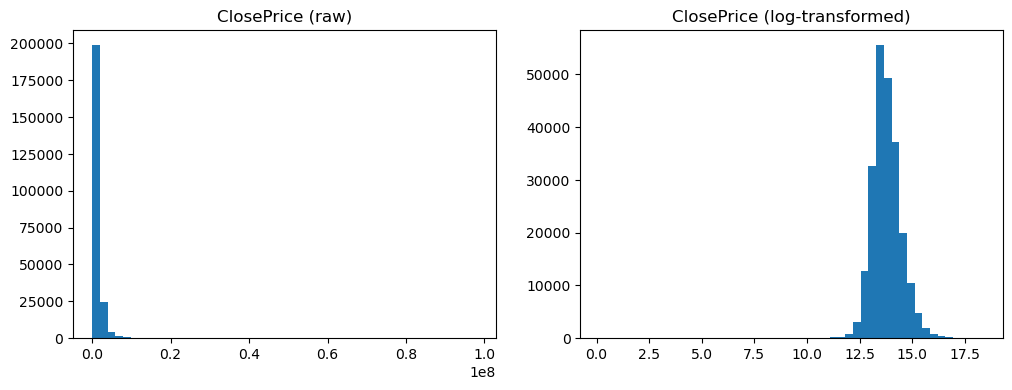

In [7]:
df['ClosePrice_log'] = np.log(df['ClosePrice'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['ClosePrice'], bins=50)
axes[0].set_title('ClosePrice (raw)')
axes[1].hist(df['ClosePrice_log'], bins=50)
axes[1].set_title('ClosePrice (log-transformed)')
plt.show()

## 7. Save Checkpoint (before geocoding merge)

In [8]:
df.to_csv("data/df_before_geocoding.csv", index=False)
print('Saved: data/df_before_geocoding.csv')

Saved: data/df_before_geocoding.csv


# 02 - Data Preprocessing — Summary

**What this notebook does:**
1. Loads all 21 CRMLS files, combines them, applies dual filter (Residential + SingleFamilyResidence)
2. Cleans ClosePrice — removes fake outliers (>$100M) and $0/negative rows
3. Fills missing values (LivingArea, BathroomsTotalInteger, YearBuilt) with median
4. Fixes LotSizeSquareFeet outliers (>10 acres treated as missing), fills with median
5. Flags rows missing Lat/Long, saves them separately for geocoding (→ `03_geocoding.ipynb`)
6. Log-transforms ClosePrice to fix right-skew (new column: `ClosePrice_log`)
7. Saves checkpoint: `data/df_before_geocoding.csv`

**Still needed (not in this notebook):**
- Geocode missing Lat/Long → `03_geocoding.ipynb`
- Encode categorical variables
- Train/test split

**Final row count after cleaning:** 230,316 rows